# impute the missing value in titanics dataset in different ways:

In [2]:
# import libreries:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# load the dataset:
df = sns.load_dataset('titanic')

In [4]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [6]:
df.isnull().sum().sort_values(ascending=False)

deck           688
age            177
embarked         2
embark_town      2
sex              0
pclass           0
survived         0
fare             0
parch            0
sibsp            0
class            0
adult_male       0
who              0
alive            0
alone            0
dtype: int64

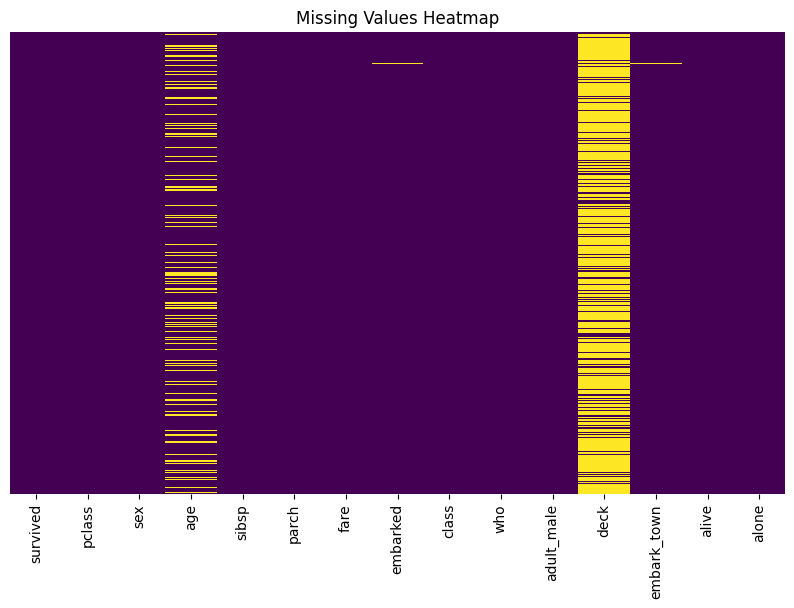

In [7]:
# visualize missing values using heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

In [8]:
#Remove the missing values in 'age' column:
df['age'].dropna(inplace=True)
df['age'].isnull().sum()

np.int64(177)

In [9]:
df.isnull().sum().sort_values(ascending=False)

deck           688
age            177
embarked         2
embark_town      2
sex              0
pclass           0
survived         0
fare             0
parch            0
sibsp            0
class            0
adult_male       0
who              0
alive            0
alone            0
dtype: int64

In [10]:
#impute the mean age and fill the missing values in 'age' column:
mean_age = df['age'].mean()
df['age'].fillna(mean_age, inplace=True)
df['age'].isnull().sum()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_7524\4134608392.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(mean_age, inplace=True)


np.int64(0)

In [11]:
df.isnull().sum().sort_values(ascending=False)

deck           688
embarked         2
embark_town      2
age              0
survived         0
pclass           0
sex              0
fare             0
parch            0
sibsp            0
class            0
adult_male       0
who              0
alive            0
alone            0
dtype: int64

In [12]:
#impute the mean age and fill the missing values in 'deck' column:
mode_deck = df['deck'].mode()[0]
df['deck'].fillna(mode_deck, inplace=True)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_7524\1038946988.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['deck'].fillna(mode_deck, inplace=True)


In [13]:
df.isnull().sum().sort_values(ascending=False)

embarked       2
embark_town    2
survived       0
age            0
sibsp          0
pclass         0
sex            0
fare           0
parch          0
who            0
class          0
adult_male     0
deck           0
alive          0
alone          0
dtype: int64

In [14]:
#check the duplicate rows in the dataset:
duplicate_rows = df.duplicated()
print("Number of duplicate rows:", duplicate_rows.sum())


Number of duplicate rows: 108


In [17]:
df.duplicated().sort_values(ascending=False)

466     True
560     True
133     True
358     True
355     True
       ...  
305    False
306    False
307    False
308    False
890    False
Length: 891, dtype: bool

In [18]:
# Remove duplicate rows:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [22]:
# create two dataframes which have merged together with some common columns:
data1 = {
    'id': [1, 2, 3, 4],
    'name': ['Alice', 'Bob', 'Charlie', 'David'],
    'age': [25, 30, 35, 40]
}
data2 = {
    'id': [3, 4, 5, 6],
    'name': ['Charlie', 'David', 'Eve', 'Frank'],
    'salary': [70000, 80000, 90000, 100000]
}
df1 = pd.DataFrame(data1)
df2 = pd.DataFrame(data2)
# Merge the two dataframes on 'id' and 'name' columns:
merged_df = pd.merge(df1, df2, on=['id', 'name'], how='inner')
print(merged_df)

   id     name  age  salary
0   3  Charlie   35   70000
1   4    David   40   80000
